In [98]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [10]:
# All helper functions
eps = 1e-5
min_val = -1 + eps
max_val = 1 - eps

def val(min_val, max_val):
    return round(np.random.uniform(min_val, max_val), 2)

def class_for_val(val1, val2):
    k = np.pi
    return int(val2 >= -1/4 + 3/4*np.sin(val1*k))

def create_dataset(n_points, min_val, max_val):
    val1_list = np.array([val(min_val, max_val) for _ in range(n_points)])
    val2_list = np.array([val(min_val, max_val) for _ in range(n_points)])
    inputs = np.array([[v1, v2] for v1, v2 in zip(val1_list, val2_list)])
    outputs = np.array([class_for_val(v1, v2) for v1, v2 in zip(val1_list, val2_list)]).reshape(n_points, 1)
    return val1_list, val2_list, inputs, outputs

In [17]:
# Generate dataset
n_points = 100
np.random.seed(47)
# This sets the random seed for NumPy's random number generator to 47, ensuring that the random numbers generated are reproducible.

val1_list, val2_list, inputs, outputs = create_dataset(n_points, min_val, max_val)

print("val1_list = " , val1_list.shape)
print("val2_list = " , val2_list.shape)
print("inputs = " , inputs.shape)
print("outputs = " , outputs.shape)

print("val1_list[:5] = ", val1_list[:5,])
print("val2_list[:5] = ", val2_list[:5,])  
print("inputs[:5] = ", inputs[:5,])
print("outputs[:5] = ", outputs[:5,])

val1_list =  (100,)
val2_list =  (100,)
inputs =  (100, 2)
outputs =  (100, 1)
val1_list[:5] =  [-0.77  0.95  0.46 -0.3   0.42]
val2_list[:5] =  [ 0.1   0.6  -0.37 -0.92  0.62]
inputs[:5] =  [[-0.77  0.1 ]
 [ 0.95  0.6 ]
 [ 0.46 -0.37]
 [-0.3  -0.92]
 [ 0.42  0.62]]
outputs[:5] =  [[1]
 [1]
 [0]
 [0]
 [1]]


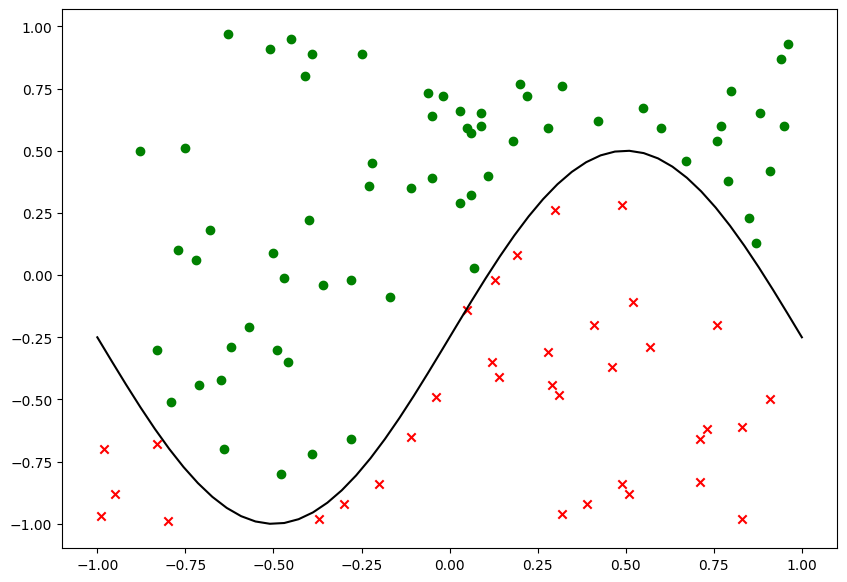

In [18]:
# Initialize plot
fig = plt.figure(figsize = (10, 7))

# Scatter plot
markers = {0: "x", 1: "o"}
colors = {0: "r", 1: "g"}
indexes_0 = np.where(outputs == 0)[0]
v1_0 = val1_list[indexes_0]
v2_0 = val2_list[indexes_0]
indexes_1 = np.where(outputs == 1)[0]
v1_1 = val1_list[indexes_1]
v2_1 = val2_list[indexes_1]
plt.scatter(v1_0, v2_0, c = colors[0], marker = markers[0])
plt.scatter(v1_1, v2_1, c = colors[1], marker = markers[1])
    
# Display true boundary
x1 = [v1 for v1 in np.linspace(min_val, max_val, 50)]
x2_true = [-1/4 + 3/4*np.sin(v1*np.pi) for v1 in x1]
plt.plot(x1, x2_true, "k", label = "True boundary")

# Show
plt.show()

| Variable | Shape | Note |                                                                                                                                     
  |----------|-------|------|                                                                                                                                     
  | X | (m, n_x) | m samples, n_x features each |                                                                                                                 
  | W1 | (n_x, n_h) | |                                                                                                                                           
  | b1 | (1, n_h) | |                                                                                                                                             
  | Z1 | (m, n_h) | Z1 = X · W1 + b1 |                                                                                                                            
  | W2 | (n_h, n_y) | |                                                                                                                                           
  | b2 | (1, n_y) | |                                                                                                                                             
  | ŷ | (m, n_y) | ŷ = Z1 · W2 + b2 |

  Each matrix multiplication shrinks/expands the feature dimension while preserving m (number of samples) as the row count throughout:

  `(m, n_x) · (n_x, n_h) → (m, n_h) · (n_h, n_y) → (m, n_y)`

  `X → W1 → Z1 → W2 → ŷ`

Gradient calculation during backprop through `y_pred = Z1 @ W2 + b2` and `Z1 = X @ W1 + b1`:                                                                                       
                                                                                                                                                                  
  | Gradient | Formula |                                                                                                                                          
  |----------|---------|                                                                                                                                          
  | `∂L/∂W2` | `(1/m) Z1ᵀ · (∂L/∂ŷ)` |                                                                                                                            
  | `∂L/∂b2` | `(1/m) Σ (∂L/∂ŷ)` |                                                                                                                                
  | `∂L/∂W1` | `(1/m) Xᵀ · (∂L/∂ŷ · W2ᵀ)` |                                                                                                                       
  | `∂L/∂b1` | `(1/m) Σ (∂L/∂ŷ · W2ᵀ)` |                                                                                                                          

  The factor of 2 is often dropped (absorbed into the learning rate) since it doesn't change the gradient direction, only magnitude.

| Gradient | Chain Rule | Why (from forward pass) | Local Derivatives | Result |                                                                                
  | --- | --- | --- | --- | --- |                                                                                                                                 
  | ∂L/∂ŷ | - | L = (1/m) Σ (y - ŷ)² | From MSE: (2/m)(ŷ - y) | (2/m)(ŷ - y) |                                                                                    
  | ∂L/∂W2 | ∂L/∂ŷ · ∂ŷ/∂W2 | ŷ = Z1·W2 + b2, differentiate w.r.t W2 | ∂ŷ/∂W2 = Z1ᵀ | (1/m) Z1ᵀ · (∂L/∂ŷ) |                                                       
  | ∂L/∂b2 | ∂L/∂ŷ · ∂ŷ/∂b2 | ŷ = Z1·W2 + b2, differentiate w.r.t b2 | ∂ŷ/∂b2 = 1 | (1/m) Σ (∂L/∂ŷ) |
  | ∂L/∂Z1 | ∂L/∂ŷ · ∂ŷ/∂Z1 | ŷ = Z1·W2 + b2, differentiate w.r.t Z1 | ∂ŷ/∂Z1 = W2ᵀ | ∂L/∂ŷ · W2ᵀ |                                                               
  | ∂L/∂W1 | ∂L/∂Z1 · ∂Z1/∂W1 | Z1 = X·W1 + b1, differentiate w.r.t W1 | ∂Z1/∂W1 = Xᵀ | (1/m) Xᵀ · (∂L/∂ŷ · W2ᵀ) |                                                
  | ∂L/∂b1 | ∂L/∂Z1 · ∂Z1/∂b1 | Z1 = X·W1 + b1, differentiate w.r.t b1 | ∂Z1/∂b1 = 1 | (1/m) Σ (∂L/∂ŷ · W2ᵀ) | 

In [192]:
# Shallow Neural Network

class ShallowNeuralNetwork:
    def __init__(self, nx, nh, ny, init_type="random"):
        # Network architecture
        self.nx = nx
        self.nh = nh
        self.ny = ny
        self.input = None
        self.output = None
        
        self.initialize_parameters(init_type)

    def initialize_parameters(self, init_type):
        # Initialize weights and biases
        match init_type:
            case "xavier":
                self.init_parameters_xavier()
            case "const":
                self.init_parameters_const()
            case "weird":
                self.init_parameters_weird()
            case _:
                self.init_parameters_random()

    def init_parameters_random(self):
        self.W1 = np.random.randn(self.nx, self.nh) * 0.01
        self.b1 = np.zeros((1, self.nh))
        self.W2 = np.random.randn(self.nh, self.ny) * 0.01
        self.b2 = np.zeros((1, self.ny))

    def init_parameters_weird(self):
        # Weights and biases matrices (Weird? initialized)
        init_val = np.sqrt(6.0/(self.nx + self.ny))
        self.W1 = np.random.uniform(-init_val, init_val, (self.nx, self.nh))
        self.b1 = np.random.uniform(-init_val, init_val, (1, self.nh))
        self.W2 = np.random.uniform(-init_val, init_val, (self.nh, self.ny))
        self.b2 = np.random.uniform(-init_val, init_val, (1, self.ny))

    def init_parameters_xavier(self):
    # Weights and biases matrices (Xavier initialized)
        var = np.sqrt(2.0/(self.nx + self.ny))
        self.W1 = np.random.randn(self.nx, self.nh)*var
        self.b1 = np.random.randn(1, self.nh)*var
        self.W2 = np.random.randn(self.nh, self.ny)*var
        self.b2 = np.random.randn(1, self.ny)*var

    def init_parameters_const(self, const_val = 0.1):
        # Weights and biases matrices (Constant initialized)
        self.W1 = np.ones(shape = (self.nx, self.nh))*const_val
        self.b1 = np.ones(shape = (1, self.nh))*const_val
        self.W2 = np.ones(shape = (self.nh, self.ny))*const_val
        self.b2 = np.ones(shape = (1, self.ny))*const_val

    def initialize_training_dataset(self, input, output):
        self.input = input
        self.output = output

    def forward(self):
        if(self.input is None or self.output is None):
            raise ValueError("Training dataset not initialized.")

                
        # Wx + b operation for the first layer
        Z1 = np.matmul(self.input, self.W1)
        Z1_b = Z1 + self.b1

        # Wx + b operation for the second layer
        Z2 = np.matmul(Z1_b, self.W2)
        Z2_b = Z2 + self.b2
        return Z1_b, Z2_b

    def MSE_loss(self, pred):
        if(self.input is None or self.output is None):
            raise ValueError("Training dataset not initialized.")
        
        outputs_re = self.output.reshape(-1,1) 
        # Reshaping is done to ensure that the dimensions match for the loss calculation
        # The model's output is typically 2D (batch_size, 1), and we want to compare it with the true labels
        # which are also reshaped to be 2D
        # The -1 means "infer this dimension automatically" — so reshape(-1, 1) means "give me 1 column, figure out how many rows."        
    
        #calculates the squared difference between the predicted values and the true labels, which is the basis for the Mean Squared Error loss
        losses = (pred - outputs_re)**2 

        # calculates the average loss over all samples in the batch
        self.loss = np.sum(losses)/outputs_re.shape[0]
        return self.loss


    def backward(self, alpha=1e-5):
        if (self.input is None or self.output is None):
            raise ValueError("Training dataset not initialized.")
        
        # Get the number of samples in the dataset
        m = self.input.shape[0]

        # Forward pass to get predictions
        Z1, Z2 = self.forward()

        # Calculate the gradient of the loss with respect to the predictions
        epsilon = Z2 - self.output
        dL_dW2 = (2/m) * np.matmul(Z1.T, epsilon)
        dL_db2 = (2/m) * np.sum(epsilon, axis=0, keepdims=True)

        # Compute the loss derivative with respect to the first layer
        dL_dZ1 = np.matmul(epsilon, self.W2.T)

        # Compute the gradient for W1 and b1
        dL_dW1 = (2/m)*np.matmul(self.input.T, dL_dZ1)
        dL_db1 = (2/m)*np.sum(dL_dZ1, axis = 0, keepdims = True)

        # Update the weights and biases using gradient descent
        self.W1 -= alpha*dL_dW1
        self.b1 -= alpha*dL_db1
        self.W2 -= alpha*dL_dW2
        self.b2 -= alpha*dL_db2

    # Training
    def train(self, epochs, alpha=1e-5, delta=1e-5, display=False, print_loss_every=10):
        if(self.input is None or self.output is None):
            raise ValueError("Training dataset not initialized.")
        
        losses_list = []
        
        prev_loss = float('inf')
        for epoch in range(epochs):
            self.backward(alpha=alpha)
            Z1, Z2 = self.forward()
            loss = self.MSE_loss(Z2)

            if display and epoch % print_loss_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")
            losses_list.append(loss)
            
            if(epoch > 0 and abs(prev_loss - loss) < delta):
                print(f"Early stopping at epoch {epoch} due to minimal loss improvement.")
                break

            prev_loss = loss
        return losses_list

    def print_predictions_table(self, pred, n=20):                                                                                                                  
        if(self.input is None or self.output is None):                                                                                                              
            raise ValueError("Training dataset not initialized.")
                                                                                                                                                                    
        loss = self.output - pred                                                                                                                                   
                                                                                                                                                                    
        def format_array(arr):
            return np.array2string(arr, precision=4, separator=', ')

        params_html = f"""
        <table>
            <tr><th>Parameter</th><th>Shape</th><th>Values</th></tr>
            <tr><td>W1</td><td>{self.W1.shape}</td><td><pre>{format_array(self.W1)}</pre></td></tr>
            <tr><td>b1</td><td>{self.b1.shape}</td><td><pre>{format_array(self.b1)}</pre></td></tr>
            <tr><td>W2</td><td>{self.W2.shape}</td><td><pre>{format_array(self.W2)}</pre></td></tr>
            <tr><td>b2</td><td>{self.b2.shape}</td><td><pre>{format_array(self.b2)}</pre></td></tr>
        </table><br>"""

        rows = ""
        for i in range(n):
            x = self.input[i]
            rows += f"""<tr>
                <td>[{x[0]:.2f}, {x[1]:.2f}]</td>
                <td>{self.output[i,0]}</td>
                <td>{pred[i,0]:.4f}</td>
                <td>{loss[i,0]:.4f}</td>
            </tr>"""

        pred_html = f"""<table>
            <tr><th>Input</th><th>Output</th><th>Prediction</th><th>Loss</th></tr>
            {rows}
        </table>"""
        display(HTML(params_html + pred_html))
            
    def print_network_architecture(self):
        if(self.nx is None or self.nh is None or self.ny is None):
            print("Network architecture not defined.")
            return
        
        if(self.input is None or self.output is None):
            print("Training dataset not initialized.")
            return
        
        print("Network architecture")
        print("Input layer size (nx) = ", self.nx)
        print("Hidden layer size (nh) = ", self.nh)
        print("Output layer size (ny) = ", self.ny)

        print("Input layer dimensions = ", self.input.shape)

        print("W1 dimensions = ", self.W1.shape)
        print("b1 dimensions = ", self.b1.shape)
     
        print("Hidden layer dimensions = ")

        print("W2 dimensions = ", self.W2.shape)
        print("b2 dimensions = ", self.b2.shape)

        print("Output layer dimensions = ", self.output.shape)
        

In [194]:
network = ShallowNeuralNetwork(nx = 2, nh = 4, ny = 1, init_type="const")
network.initialize_training_dataset(inputs, outputs)

network.print_network_architecture()



Network architecture
Input layer size (nx) =  2
Hidden layer size (nh) =  4
Output layer size (ny) =  1
Input layer dimensions =  (100, 2)
W1 dimensions =  (2, 4)
b1 dimensions =  (1, 4)
Hidden layer dimensions = 
W2 dimensions =  (4, 1)
b2 dimensions =  (1, 1)
Output layer dimensions =  (100, 1)


In [165]:
print("Performing forward pass to get predictions")
Z1,Z2 = network.forward()
# print("Predictions = ", pred)

network.print_predictions_table(Z2)
loss = network.MSE_loss(Z2)

print("MSE Loss = ", loss)

Performing forward pass to get predictions


MSE Loss =  0.4750260112000001


In [166]:
print ("Weights and biases updated after backward pass.")
# Backward pass to update weights and biases
network.backward(alpha=1e-2)
Z1, Z2 = network.forward()
network.print_predictions_table(Z2)

loss = network.MSE_loss(Z2)
print("MSE Loss = ", loss)

Weights and biases updated after backward pass.


MSE Loss =  0.4636780130532163


In [198]:
network = ShallowNeuralNetwork(nx = 2, nh = 4, ny = 1, init_type="const")
network.initialize_training_dataset(inputs, outputs)
losses_list = network.train(epochs=10000, alpha=1e-2, delta=1e-6, display=True)

Epoch 0, Loss: 0.463678
Epoch 10, Loss: 0.372788
Epoch 20, Loss: 0.313044
Epoch 30, Loss: 0.273884
Epoch 40, Loss: 0.248203
Epoch 50, Loss: 0.231256
Epoch 60, Loss: 0.219909
Epoch 70, Loss: 0.212112
Epoch 80, Loss: 0.206541
Epoch 90, Loss: 0.202347
Epoch 100, Loss: 0.198991
Epoch 110, Loss: 0.196134
Epoch 120, Loss: 0.193565
Epoch 130, Loss: 0.191153
Epoch 140, Loss: 0.188817
Epoch 150, Loss: 0.186509
Epoch 160, Loss: 0.184201
Epoch 170, Loss: 0.181875
Epoch 180, Loss: 0.179525
Epoch 190, Loss: 0.177147
Epoch 200, Loss: 0.174741
Epoch 210, Loss: 0.172308
Epoch 220, Loss: 0.169853
Epoch 230, Loss: 0.167380
Epoch 240, Loss: 0.164894
Epoch 250, Loss: 0.162401
Epoch 260, Loss: 0.159908
Epoch 270, Loss: 0.157420
Epoch 280, Loss: 0.154945
Epoch 290, Loss: 0.152489
Epoch 300, Loss: 0.150059
Epoch 310, Loss: 0.147660
Epoch 320, Loss: 0.145299
Epoch 330, Loss: 0.142982
Epoch 340, Loss: 0.140715
Epoch 350, Loss: 0.138502
Epoch 360, Loss: 0.136348
Epoch 370, Loss: 0.134258
Epoch 380, Loss: 0.1322

Early stopping at epoch 1634 due to minimal loss improvement.
Early stopping at epoch 1090 due to minimal loss improvement.


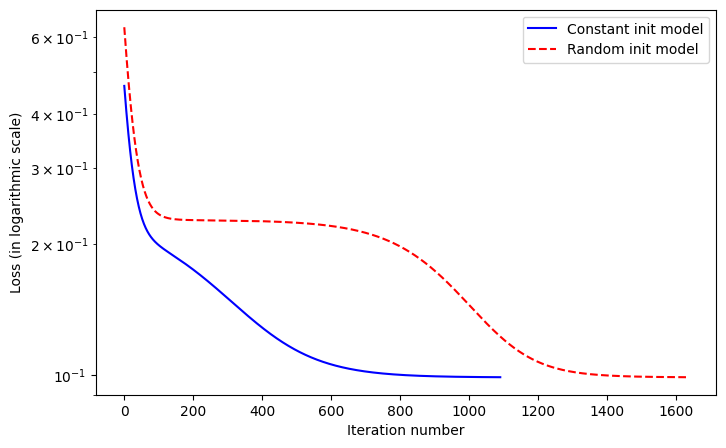

In [203]:
random_network = ShallowNeuralNetwork(nx = 2, nh = 4, ny = 1, init_type="random")
random_network.initialize_training_dataset(inputs, outputs)
losses_random_network = random_network.train(epochs=10000, alpha=1e-2, delta=1e-6, display=False)

const_network = ShallowNeuralNetwork(nx = 2, nh = 4, ny = 1, init_type="const")
const_network.initialize_training_dataset(inputs, outputs)
losses_const_network = const_network.train(epochs=10000, alpha=1e-2, delta=1e-6, display=False)

# Plot
# Compare training curves
fig = plt.figure(figsize = (8, 5))
plt.plot(list(range(len(losses_const_network))), \
            losses_const_network, \
            "b", label = "Constant init model")
plt.plot(list(range(len(losses_random_network))), \
            losses_random_network, \
            "r--", label = "Random init model")
plt.xlabel("Iteration number")
plt.ylabel("Loss (in logarithmic scale)")
plt.yscale("log")
# Display
plt.legend(loc = "best")
plt.show()

In [210]:
# Weird initialization
np.random.seed(37)
weird_network = ShallowNeuralNetwork(nx = 2, nh = 4, ny = 1, init_type="weird")
weird_network.initialize_training_dataset(inputs, outputs)
losses_list = weird_network.train(epochs=100000, alpha=1e-6, delta=1e-6, display=True, print_loss_every=10000)

Epoch 0, Loss: 3.452010
Epoch 10000, Loss: 2.861281
Epoch 20000, Loss: 2.399814
Epoch 30000, Loss: 2.034054
Epoch 40000, Loss: 1.740452
Epoch 50000, Loss: 1.502112
Epoch 60000, Loss: 1.306677
Epoch 70000, Loss: 1.144962
Epoch 80000, Loss: 1.010036
Epoch 90000, Loss: 0.896602
